# PET Sequence Distribution Analysis
Analyzing the distribution of image sequences in the preprocessed PET data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

path = 'preprocessed/PET/up_threshold_0.8'

In [ ]:
# scan all .npy files and collect sequence lengths
base_path = Path(path)
sequence_lengths = []
file_info = []

for disease_dir in base_path.iterdir():
    if disease_dir.is_dir():
        for npy_file in disease_dir.glob('*.npy'):
            data = np.load(npy_file)
            seq_length = data.shape[0]
            sequence_lengths.append(seq_length)
            file_info.append({
                'file': npy_file.name,
                'disease': disease_dir.name,
                'length': seq_length,
                'path': str(npy_file)
            })

sequence_lengths = np.array(sequence_lengths)
print(f"Total files scanned: {len(sequence_lengths)}")
print(f"\nSequence Length Statistics:")
print(f"  Min: {sequence_lengths.min()}")
print(f"  Max: {sequence_lengths.max()}")
print(f"  Mean: {sequence_lengths.mean():.2f}")
print(f"  Median: {np.median(sequence_lengths):.2f}")
print(f"  Std Dev: {sequence_lengths.std():.2f}")

Total files scanned: 133

Sequence Length Statistics:
  Min: 6
  Max: 382
  Mean: 90.22
  Median: 54.00
  Std Dev: 91.34


In [3]:
# Find files with min and max sequence lengths
min_idx = np.argmin(sequence_lengths)
max_idx = np.argmax(sequence_lengths)

min_file_info = file_info[min_idx]
max_file_info = file_info[max_idx]

print(f"\nMinimum Sequence:")
print(f"  File: {min_file_info['file']}")
print(f"  Disease: {min_file_info['disease']}")
print(f"  Length: {min_file_info['length']} slices")

print(f"\nMaximum Sequence:")
print(f"  File: {max_file_info['file']}")
print(f"  Disease: {max_file_info['disease']}")
print(f"  Length: {max_file_info['length']} slices")


Minimum Sequence:
  File: Lung-PET-CT-Dx-A0169.npy
  Disease: A
  Length: 6 slices

Maximum Sequence:
  File: Lung-PET-CT-Dx-A0206.npy
  Disease: A
  Length: 382 slices


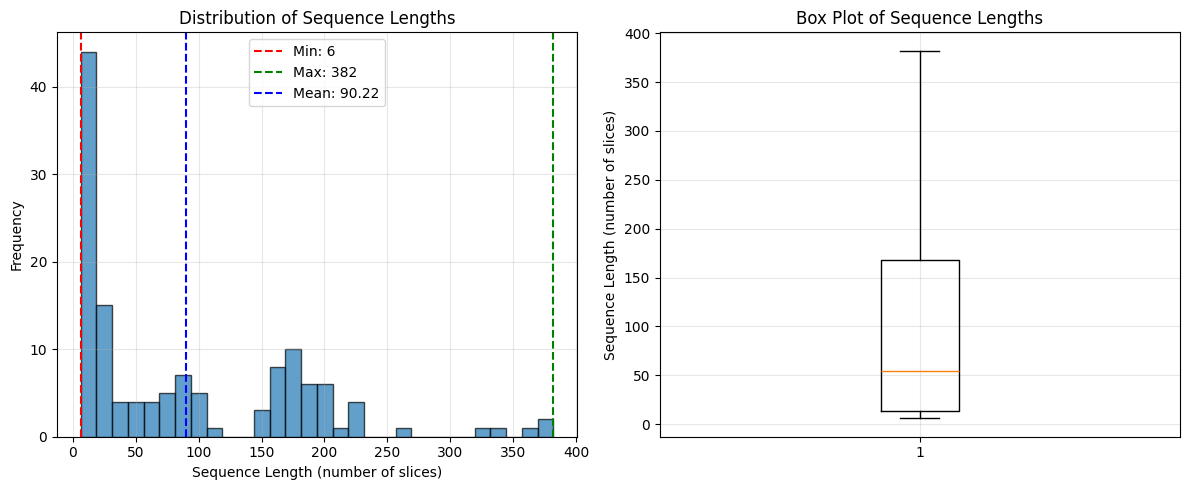

In [4]:
# Plot distribution of sequence lengths
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sequence_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(sequence_lengths.min(), color='red', linestyle='--', label=f'Min: {sequence_lengths.min()}')
plt.axvline(sequence_lengths.max(), color='green', linestyle='--', label=f'Max: {sequence_lengths.max()}')
plt.axvline(sequence_lengths.mean(), color='blue', linestyle='--', label=f'Mean: {sequence_lengths.mean():.2f}')
plt.xlabel('Sequence Length (number of slices)')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(sequence_lengths, vert=True)
plt.ylabel('Sequence Length (number of slices)')
plt.title('Box Plot of Sequence Lengths')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize Minimum Sequence

Min Sequence Shape: (6, 128, 128)


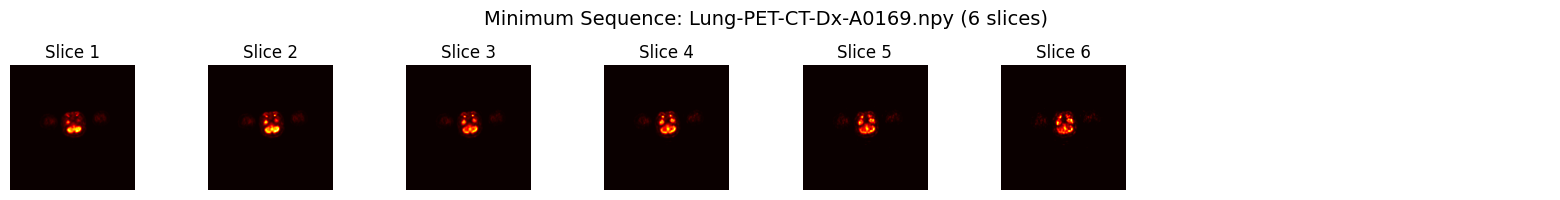

In [5]:
# Load and visualize minimum sequence
min_data = np.load(min_file_info['path'])
print(f"Min Sequence Shape: {min_data.shape}")

# Plot all slices of minimum sequence
num_slices = min_data.shape[0]
cols = 8
rows = (num_slices + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes = axes.flatten() if rows > 1 else [axes] if num_slices == 1 else axes

for i in range(num_slices):
    axes[i].imshow(min_data[i], cmap='hot')
    axes[i].set_title(f'Slice {i+1}')
    axes[i].axis('off')

# Hide unused subplots
for i in range(num_slices, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Minimum Sequence: {min_file_info["file"]} ({num_slices} slices)', fontsize=14)
plt.tight_layout()
plt.show()

## Visualize Maximum Sequence

Max Sequence Shape: (382, 128, 128)


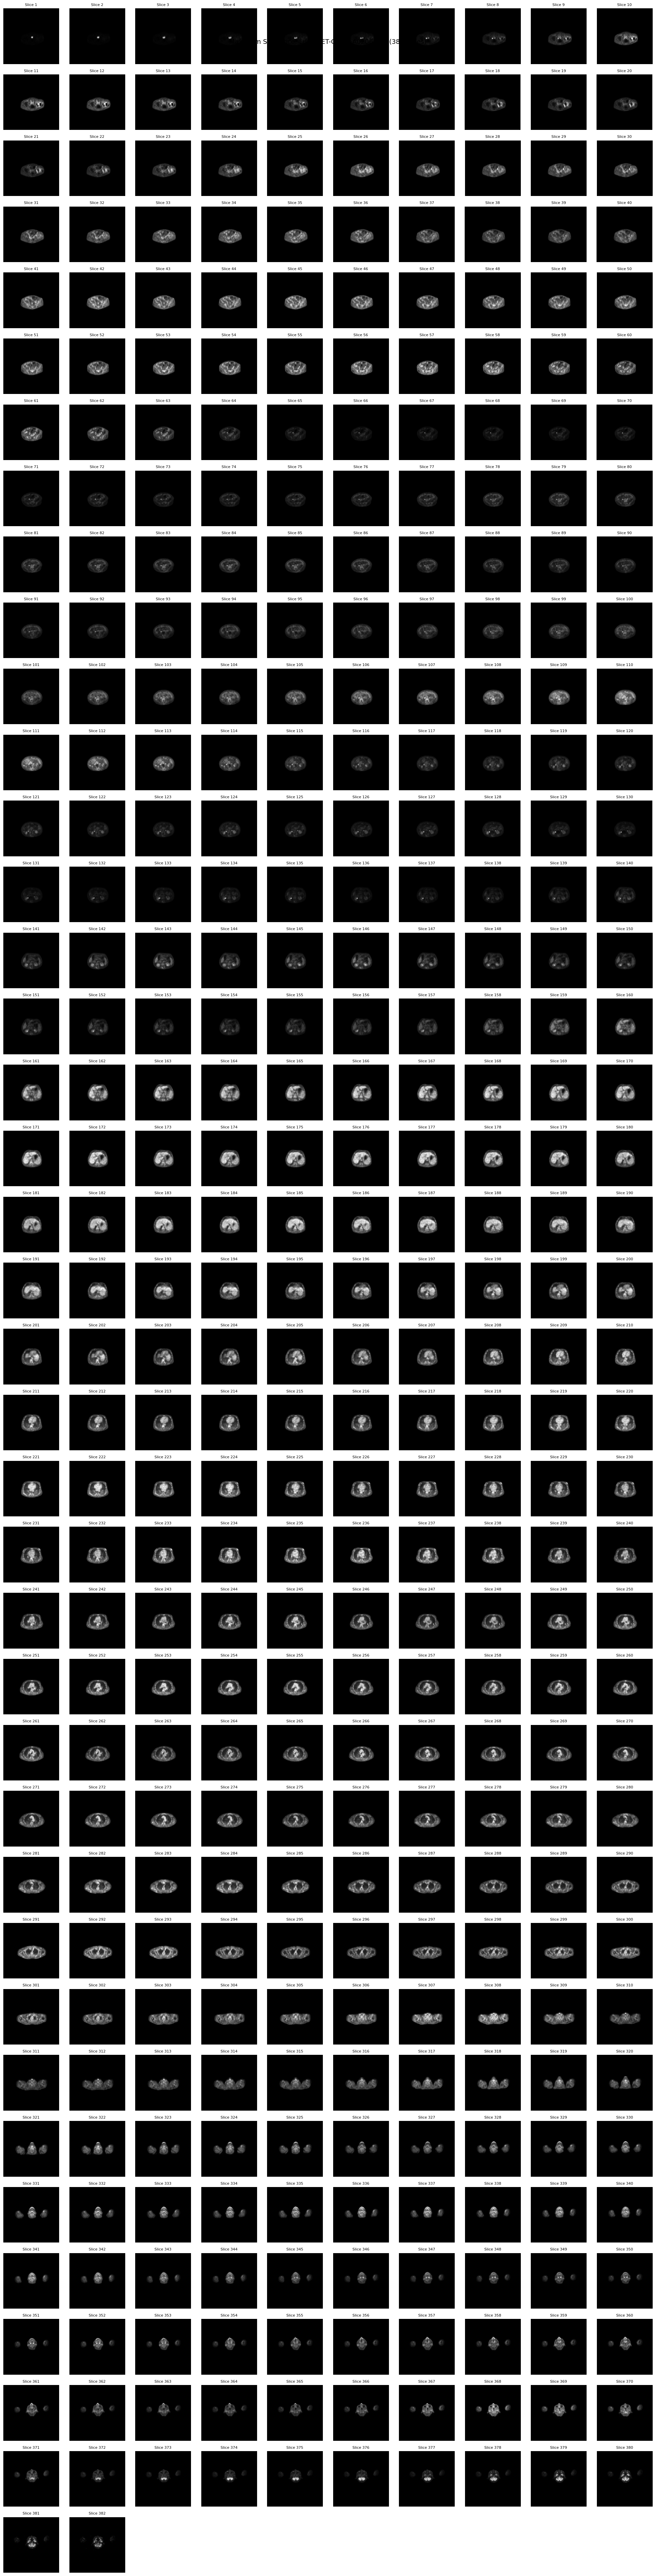

In [6]:
# Load and visualize maximum sequence
max_data = np.load(max_file_info['path'])
print(f"Max Sequence Shape: {max_data.shape}")

# Plot all slices of maximum sequence
num_slices = max_data.shape[0]
cols = 10
rows = (num_slices + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2))
axes = axes.flatten()

for i in range(num_slices):
    axes[i].imshow(max_data[i], cmap='gray')
    axes[i].set_title(f'Slice {i+1}', fontsize=8)
    axes[i].axis('off')

# Hide unused subplots
for i in range(num_slices, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Maximum Sequence: {max_file_info["file"]} ({num_slices} slices)', fontsize=14)
plt.tight_layout()
plt.show()

## Sequence Count Analysis

In [7]:
# Calculate statistical thresholds
median_val = np.median(sequence_lengths)
mean_val = sequence_lengths.mean()
q3_val = np.percentile(sequence_lengths, 75)

# Count sequences above each threshold
count_above_median = np.sum(sequence_lengths > median_val)
count_above_mean = np.sum(sequence_lengths > mean_val)
count_above_q3 = np.sum(sequence_lengths > q3_val)

total_sequences = len(sequence_lengths)

print("=" * 60)
print("SEQUENCE COUNT ANALYSIS")
print("=" * 60)
print(f"\nTotal sequences: {total_sequences}")
print(f"\nStatistical Thresholds:")
print(f"  Median: {median_val:.2f} slices")
print(f"  Mean: {mean_val:.2f} slices")
print(f"  3rd Quartile (Q3): {q3_val:.2f} slices")
print(f"\nSequences ABOVE thresholds:")
print(f"  > Median: {count_above_median} sequences ({count_above_median/total_sequences*100:.1f}%)")
print(f"  > Mean: {count_above_mean} sequences ({count_above_mean/total_sequences*100:.1f}%)")
print(f"  > 3rd Quartile: {count_above_q3} sequences ({count_above_q3/total_sequences*100:.1f}%)")
print("=" * 60)

SEQUENCE COUNT ANALYSIS

Total sequences: 133

Statistical Thresholds:
  Median: 54.00 slices
  Mean: 90.22 slices
  3rd Quartile (Q3): 168.00 slices

Sequences ABOVE thresholds:
  > Median: 66 sequences (49.6%)
  > Mean: 51 sequences (38.3%)
  > 3rd Quartile: 33 sequences (24.8%)


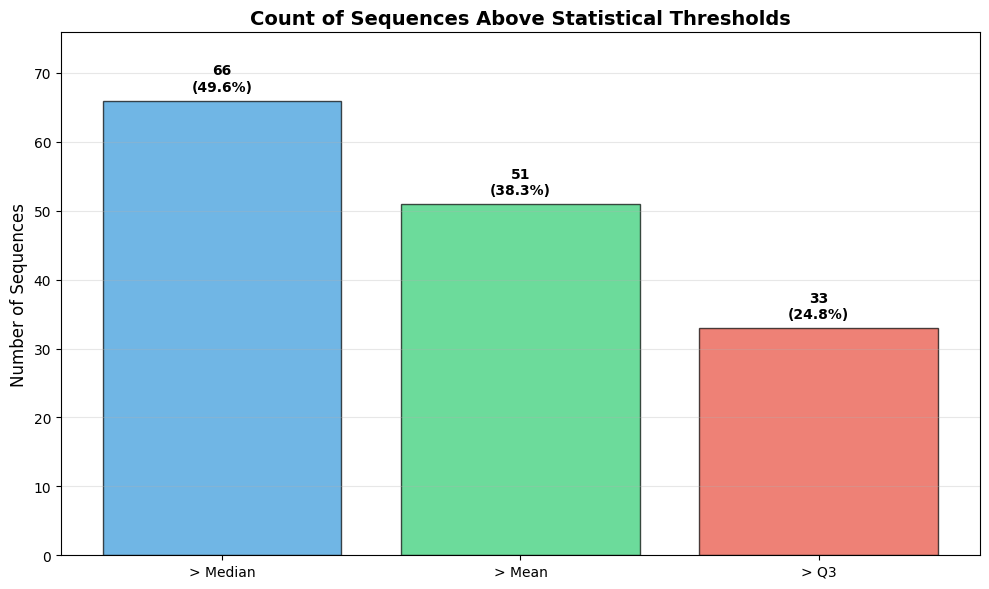

In [8]:
# Visualize the threshold counts
fig, ax = plt.subplots(figsize=(10, 6))

thresholds = ['> Median', '> Mean', '> Q3']
counts = [count_above_median, count_above_mean, count_above_q3]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(thresholds, counts, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{count}\n({count/total_sequences*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Number of Sequences', fontsize=12)
ax.set_title('Count of Sequences Above Statistical Thresholds', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.show()

In [9]:
# Filter and display sequences with length > 3rd quartile
sequences_above_q3 = [(info['file'], info['disease'], info['length']) 
                      for info in file_info if info['length'] > q3_val]

print("=" * 80)
print(f"SEQUENCES WITH LENGTH > 3rd QUARTILE ({q3_val:.2f} slices)")
print("=" * 80)
print(f"\nTotal sequences above Q3: {len(sequences_above_q3)}\n")
print(f"{'File Name':<40} {'Disease':<10} {'Slices':<10}")
print("-" * 80)

# Sort by slice count (descending)
sequences_above_q3.sort(key=lambda x: x[2], reverse=True)

for filename, disease, length in sequences_above_q3:
    print(f"{filename:<40} {disease:<10} {length:<10}")
    
print("=" * 80)

SEQUENCES WITH LENGTH > 3rd QUARTILE (168.00 slices)

Total sequences above Q3: 33

File Name                                Disease    Slices    
--------------------------------------------------------------------------------
Lung-PET-CT-Dx-A0206.npy                 A          382       
Lung-PET-CT-Dx-A0225.npy                 A          374       
Lung-PET-CT-Dx-A0198.npy                 A          367       
Lung-PET-CT-Dx-A0248.npy                 A          344       
Lung-PET-CT-Dx-A0240.npy                 A          328       
Lung-PET-CT-Dx-A0242.npy                 A          258       
Lung-PET-CT-Dx-A0188.npy                 A          231       
Lung-PET-CT-Dx-G0034.npy                 G          224       
Lung-PET-CT-Dx-G0056.npy                 G          223       
Lung-PET-CT-Dx-A0182.npy                 A          220       
Lung-PET-CT-Dx-A0191.npy                 A          209       
Lung-PET-CT-Dx-A0247.npy                 A          206       
Lung-PET-CT-Dx-G